In [6]:
import librosa
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
import librosa.display


In [2]:
# Load an audio file
file_path = '../data/sample.wav'
audio_data, sample_rate = librosa.load(file_path, sr=None)

# Print audio properties
print(f"Sample Rate: {sample_rate}")
print(f"Audio Shape: {audio_data.shape}")


Sample Rate: 44100
Audio Shape: (196783,)


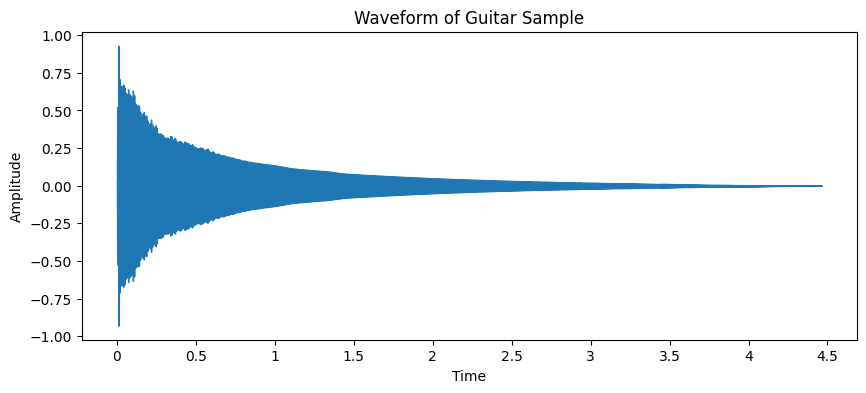

In [3]:
# Plot the waveform
plt.figure(figsize=(10, 4))
librosa.display.waveshow(audio_data, sr=sample_rate)
plt.title("Waveform of Guitar Sample")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

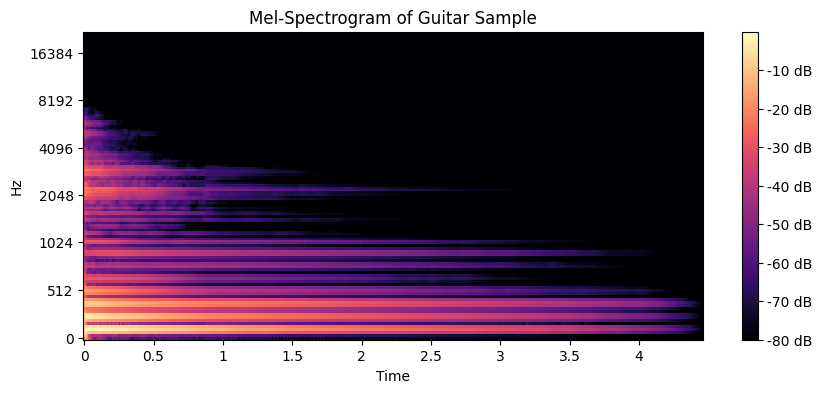

In [4]:
# Convert to Mel-Spectrogram
mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate, n_mels=128)

# Convert to decibels
mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

# Plot the Mel-Spectrogram
plt.figure(figsize=(10, 4))
librosa.display.specshow(mel_spectrogram_db, sr=sample_rate, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title("Mel-Spectrogram of Guitar Sample")
plt.show()


In [5]:


# Define the Autoencoder model
def create_autoencoder(input_shape):
    # Encoder
    input_layer = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_layer)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    # Build the autoencoder model
    autoencoder = models.Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='mse')

    return autoencoder

# Define input shape as (height, width, channels), assuming 128 Mel bands and time steps
input_shape = (128, 128, 1)  # Adjust according to your Mel-spectrogram dimensions
autoencoder = create_autoencoder(input_shape)

# Summary of the model
autoencoder.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

def preprocess_audio_for_autoencoder(audio_data, sample_rate, n_mels=128, duration=5):
    # Convert audio data to Mel-spectrogram
    mel_spectrogram = librosa.feature.melspectrogram(y=audio_data, sr=sample_rate, n_mels=n_mels)
    
    # Convert to decibel scale
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)
    
    # Resize or pad the Mel-spectrogram to fit the input shape (128x128 here)
    mel_spectrogram_resized = librosa.util.fix_length(mel_spectrogram_db, size=128)
    
    # Add channel dimension (for Conv2D)
    mel_spectrogram_resized = np.expand_dims(mel_spectrogram_resized, axis=-1)
    
    return mel_spectrogram_resized

# Example usage
mel_spec = preprocess_audio_for_autoencoder(audio_data, sample_rate)


In [8]:
# Assuming you have a dataset of Mel-spectrograms stored in X_train
# Normalize the data (optional, but helps with training)
X_train = X_train / np.max(X_train)

# Train the model
autoencoder.fit(X_train, X_train, epochs=50, batch_size=16, validation_split=0.1)


NameError: name 'X_train' is not defined